# Probe Evaluation: Activation Probes for High-Stakes Detection

Configurable notebook for training and evaluating linear probes on LLM activations.

**Supports:**
- Multiple models: Llama 3.1 8B, Llama 3.3 70B, Gemma 3
- Layer sweep: evaluate probes at any set of layers
- Cross-lingual evaluation: English vs Indonesian (when translations available)
- Caching: all activations and probes cached to disk, re-runs are instant

**Requires:** `experiments/lib/` shared library. Run `setup_lambda.sh` on remote or install deps manually.

## Part 0: Setup

In [1]:
import importlib
missing = [pkg for pkg in ["bitsandbytes", "dotenv", "accelerate"] if not importlib.util.find_spec(pkg)]
if missing:
    %pip install -U bitsandbytes python-dotenv accelerate transformers scikit-learn tqdm

In [3]:
import sys
import json
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

sys.path.insert(0, str(Path("..").resolve()))

from lib.env import (
    detect_environment, resolve_base_dir, setup_paths, get_device,
    get_gpu_vram_gb, recommend_batch_size, free_gpu_memory, setup_hf_auth,
    download_from_colab, list_cache,
)
from lib.data import ensure_datasets, get_dataset_paths, load_dataset, load_jsonl
from lib.model import load_model, get_model_short_name, MODEL_REGISTRY
from lib.activations import get_activations_cached
from lib.probe import LinearProbe
from lib.evaluation import evaluate_probe, analyze_errors

# --- Configuration ---
MODEL_NAME      = "meta-llama/Llama-3.1-8B-Instruct"
LAYERS          = [12, 16, 20, 26, 31]
EVAL_INDONESIAN = True
RANDOM_SEED     = 42

# --- Derived settings ---
ENV          = detect_environment()
BASE_DIR     = resolve_base_dir()
DEVICE       = get_device()
VRAM_GB      = get_gpu_vram_gb()
paths        = setup_paths(BASE_DIR)
DATA_DIR     = paths["data_dir"]
CACHE_DIR    = paths["cache_dir"]
MODEL_SHORT  = get_model_short_name(MODEL_NAME)
CACHE_PREFIX = f"v2b_{MODEL_SHORT}"
PARAMS_B     = MODEL_REGISTRY.get(MODEL_NAME, {}).get("params_b", 8)
BATCH_SIZE   = recommend_batch_size(VRAM_GB, PARAMS_B)

np.random.seed(RANDOM_SEED)

print(f"Model:        {MODEL_NAME}")
print(f"Short name:   {MODEL_SHORT}")
print(f"Cache prefix: {CACHE_PREFIX}")
print(f"Layers:       {LAYERS}")
print(f"Indonesian:   {EVAL_INDONESIAN}")
print(f"Environment:  {ENV}")
print(f"Device:       {DEVICE}")
print(f"VRAM:         {VRAM_GB:.1f} GB")
print(f"Batch size:   {BATCH_SIZE}")

Model:        meta-llama/Llama-3.1-8B-Instruct
Short name:   llama31_8b
Cache prefix: v2b_llama31_8b
Layers:       [12, 16, 20, 26, 31]
Indonesian:   True
Environment:  remote
Device:       cuda
VRAM:         22.1 GB
Batch size:   4


## Part 1: Auth + Load Model

In [4]:
setup_hf_auth()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [5]:
model, tokenizer = load_model(MODEL_NAME)

Loading meta-llama/Llama-3.1-8B-Instruct...
  Device: cuda | VRAM: 22.1 GB | Precision: 8-bit


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  Layers: 32 | Hidden dim: 4096 | Vocab: 128256


## Part 2: Load Data

In [6]:
DATASET_PATHS  = ensure_datasets(DATA_DIR)
train_data     = load_dataset(DATASET_PATHS["train"])
test_data      = load_dataset(DATASET_PATHS["test"])
anthropic_test = load_dataset(DATASET_PATHS["anthropic_test"])
toolace_test   = load_dataset(DATASET_PATHS["toolace_test"])

y_train     = np.array([e.label for e in train_data])
y_test      = np.array([e.label for e in test_data])
y_anthropic = np.array([e.label for e in anthropic_test])
y_toolace   = np.array([e.label for e in toolace_test])

print("English datasets:")
print(f"  Train:      {len(train_data):>5} ({y_train.sum()} high)")
print(f"  Test:       {len(test_data):>5} ({y_test.sum()} high)")
print(f"  Anthropic:  {len(anthropic_test):>5} ({y_anthropic.sum()} high)")
print(f"  ToolACE:    {len(toolace_test):>5} ({y_toolace.sum()} high)")

# Indonesian datasets (if enabled)
id_test_data = id_anthropic_test = id_toolace_test = None
y_id_test = y_id_anthropic = y_id_toolace = None

if EVAL_INDONESIAN:
    ID_DIR = DATA_DIR / "indonesian"

    # Load and filter: remove refusals (rows where translation kept original English)
    # Refusals have identical text to English version, which contaminates cross-lingual eval
    def filter_refusals(id_examples, en_examples):
        """Remove examples where Indonesian text matches English (API refusals)."""
        filtered = []
        n_refusals = 0
        for id_ex, en_ex in zip(id_examples, en_examples):
            # Compare first user message content
            id_text = next((m["content"] for m in id_ex.messages if m["role"] == "user"), "")
            en_text = next((m["content"] for m in en_ex.messages if m["role"] == "user"), "")
            if id_text == en_text:
                n_refusals += 1
            else:
                filtered.append(id_ex)
        if n_refusals > 0:
            print(f"    Filtered {n_refusals} refusals (kept original English text)")
        return filtered

    id_test_data_raw  = load_dataset(ID_DIR / "synthetic_test_id.jsonl")
    id_anthropic_raw  = load_dataset(ID_DIR / "anthropic_test_id.jsonl")
    id_toolace_raw    = load_dataset(ID_DIR / "toolace_test_id.jsonl")

    id_test_data      = filter_refusals(id_test_data_raw, test_data)
    id_anthropic_test = filter_refusals(id_anthropic_raw, anthropic_test)
    id_toolace_test   = filter_refusals(id_toolace_raw, toolace_test)

    y_id_test      = np.array([e.label for e in id_test_data])
    y_id_anthropic = np.array([e.label for e in id_anthropic_test])
    y_id_toolace   = np.array([e.label for e in id_toolace_test])

    print(f"\nIndonesian datasets (refusals filtered):")
    print(f"  Test:       {len(id_test_data):>5} ({y_id_test.sum()} high)")
    print(f"  Anthropic:  {len(id_anthropic_test):>5} ({y_id_anthropic.sum()} high)")
    print(f"  ToolACE:    {len(id_toolace_test):>5} ({y_id_toolace.sum()} high)")

Checking datasets...
  Already exists: train.jsonl
  Already exists: test.jsonl
  Already exists: anthropic_test_balanced_apr_23.jsonl
  Already exists: toolace_test_balanced_apr_22.jsonl
All datasets ready.
English datasets:
  Train:       8000 (3839 high)
  Test:        2000 (965 high)
  Anthropic:   2984 (1492 high)
  ToolACE:      734 (367 high)
    Filtered 1 refusals (kept original English text)
    Filtered 25 refusals (kept original English text)
    Filtered 1 refusals (kept original English text)

Indonesian datasets (refusals filtered):
  Test:        1950 (965 high)
  Anthropic:   2959 (1468 high)
  ToolACE:      733 (367 high)


## Part 3: Extract Activations, Train & Evaluate Probes

For each layer in LAYERS:
1. Extract activations (cached to disk)
2. Train probe on English training data
3. Evaluate on all test sets (English + Indonesian if enabled)

In [7]:
all_results = {}

for layer in LAYERS:
    print(f"\n{'='*65}")
    print(f"LAYER {layer}")
    print(f"{'='*65}")

    # -- English activations --
    X_train = get_activations_cached(
        model, tokenizer, train_data, layer,
        cache_name="train", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_test = get_activations_cached(
        model, tokenizer, test_data, layer,
        cache_name="test_synthetic", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_anthropic = get_activations_cached(
        model, tokenizer, anthropic_test, layer,
        cache_name="anthropic_test", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_toolace = get_activations_cached(
        model, tokenizer, toolace_test, layer,
        cache_name="toolace_test", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    free_gpu_memory()

    # -- Indonesian activations (if enabled) --
    X_id_test = X_id_anthropic = X_id_toolace = None
    if EVAL_INDONESIAN:
        X_id_test = get_activations_cached(
            model, tokenizer, id_test_data, layer,
            cache_name="id_test_synthetic", cache_dir=CACHE_DIR,
            cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
        )
        X_id_anthropic = get_activations_cached(
            model, tokenizer, id_anthropic_test, layer,
            cache_name="id_anthropic_test", cache_dir=CACHE_DIR,
            cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
        )
        X_id_toolace = get_activations_cached(
            model, tokenizer, id_toolace_test, layer,
            cache_name="id_toolace_test", cache_dir=CACHE_DIR,
            cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
        )
        free_gpu_memory()

    # -- Train probe --
    probe = LinearProbe(C=1e-3)
    probe.fit(X_train, y_train)
    probe.save(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{layer}.pkl")

    # -- Evaluate --
    layer_results = {}
    layer_results["en_synthetic"] = evaluate_probe(probe, X_test,      y_test,      f"EN Synthetic (L{layer})")
    layer_results["en_anthropic"] = evaluate_probe(probe, X_anthropic, y_anthropic, f"EN Anthropic (L{layer})")
    layer_results["en_toolace"]   = evaluate_probe(probe, X_toolace,   y_toolace,   f"EN ToolACE (L{layer})")

    if EVAL_INDONESIAN:
        layer_results["id_synthetic"] = evaluate_probe(probe, X_id_test,      y_id_test,      f"ID Synthetic (L{layer})")
        layer_results["id_anthropic"] = evaluate_probe(probe, X_id_anthropic, y_id_anthropic, f"ID Anthropic (L{layer})")
        layer_results["id_toolace"]   = evaluate_probe(probe, X_id_toolace,   y_id_toolace,   f"ID ToolACE (L{layer})")

    all_results[layer] = layer_results
    free_gpu_memory()

# -- Summary table --
print(f"\n{'='*65}")
print(f"AUROC SUMMARY ({MODEL_SHORT})")
print(f"{'='*65}")

datasets = ["synthetic", "anthropic", "toolace"]
header   = f"{'Layer':>6}"
for ds in datasets:
    header += f" | {'EN '+ds:>14}"
    if EVAL_INDONESIAN:
        header += f" | {'ID '+ds:>14}"
print(header)
print("-" * len(header))

for layer in LAYERS:
    row = f"{layer:>6}"
    for ds in datasets:
        en_auroc = all_results[layer][f"en_{ds}"]["auroc"]
        row += f" | {en_auroc:>14.4f}"
        if EVAL_INDONESIAN:
            id_auroc = all_results[layer][f"id_{ds}"]["auroc"]
            row += f" | {id_auroc:>14.4f}"
    print(row)


LAYER 12
Computing activations for 8000 examples (batch_size=4)...


Layer 12: 100%|██████████| 2000/2000 [02:52<00:00, 11.62it/s]


Saved to cache: v2b_llama31_8b_train_layer12.npy
Computing activations for 2000 examples (batch_size=4)...


Layer 12: 100%|██████████| 500/500 [00:44<00:00, 11.28it/s]


Saved to cache: v2b_llama31_8b_test_synthetic_layer12.npy
Computing activations for 2984 examples (batch_size=4)...


...

Saved to cache: v2b_llama31_8b_id_test_synthetic_layer31.npy
Computing activations for 2959 examples (batch_size=4)...


Layer 31: 100%|██████████| 740/740 [05:02<00:00,  2.45it/s]


Saved to cache: v2b_llama31_8b_id_anthropic_test_layer31.npy
Computing activations for 733 examples (batch_size=4)...


Layer 31: 100%|██████████| 184/184 [02:40<00:00,  1.15it/s]


Saved to cache: v2b_llama31_8b_id_toolace_test_layer31.npy

EN Synthetic (L31):
  AUROC:      0.9923
  Accuracy:   0.9575
  TPR@1%FPR:  0.8528
  TPR@5%FPR:  0.9637

EN Anthropic (L31):
  AUROC:      0.7559
  Accuracy:   0.6347
  TPR@1%FPR:  0.0992
  TPR@5%FPR:  0.2594

EN ToolACE (L31):
  AUROC:      0.7932
  Accuracy:   0.6403
  TPR@1%FPR:  0.2153
  TPR@5%FPR:  0.3569

ID Synthetic (L31):
  AUROC:      0.9795
  Accuracy:   0.9195
  TPR@1%FPR:  0.6933
  TPR@5%FPR:  0.8912

ID Anthropic (L31):
  AUROC:      0.6710
  Accuracy:   0.5667
  TPR@1%FPR:  0.0375
  TPR@5%FPR:  0.1444

ID ToolACE (L31):
  AUROC:      0.8110
  Accuracy:   0.5921
  TPR@1%FPR:  0.2153
  TPR@5%FPR:  0.4441

AUROC SUMMARY (llama31_8b)
 Layer |   EN synthetic |   ID synthetic |   EN anthropic |   ID anthropic |     EN toolace |     ID toolace
------------------------------------------------------------------------------------------------------------
    12 |         0.9961 |         0.9942 |         0.8701 |         0

## Part 4: ROC Curves

Best EN mean AUROC: layer 12 (0.8995)
Loading from cache: v2b_llama31_8b_test_synthetic_layer12.npy
Loading from cache: v2b_llama31_8b_anthropic_test_layer12.npy
Loading from cache: v2b_llama31_8b_toolace_test_layer12.npy
Loading from cache: v2b_llama31_8b_id_test_synthetic_layer12.npy
Loading from cache: v2b_llama31_8b_id_anthropic_test_layer12.npy
Loading from cache: v2b_llama31_8b_id_toolace_test_layer12.npy


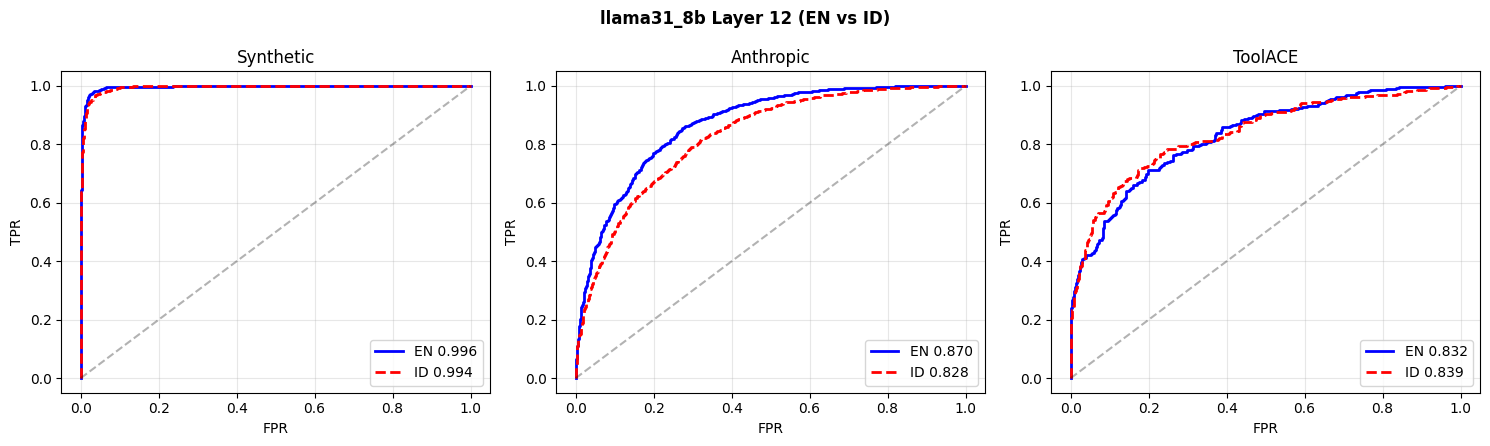

In [8]:
# pick the layer to plot (best EN mean AUROC, or the single layer if only one)
if len(LAYERS) == 1:
    plot_layer = LAYERS[0]
else:
    mean_aurocs = {
        l: np.mean([all_results[l][f"en_{ds}"]["auroc"] for ds in ["synthetic", "anthropic", "toolace"]])
        for l in LAYERS
    }
    plot_layer = max(mean_aurocs, key=mean_aurocs.get)
    print(f"Best EN mean AUROC: layer {plot_layer} ({mean_aurocs[plot_layer]:.4f})")

# reload probe for plot_layer (it was last trained in the loop, may be a different layer)
probe_plot = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{plot_layer}.pkl")

# reload activations for plot_layer (from cache -- instant)
X_test_plot      = get_activations_cached(model, tokenizer, test_data, plot_layer,
                       cache_name="test_synthetic", cache_dir=CACHE_DIR,
                       cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
X_anthropic_plot = get_activations_cached(model, tokenizer, anthropic_test, plot_layer,
                       cache_name="anthropic_test", cache_dir=CACHE_DIR,
                       cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
X_toolace_plot   = get_activations_cached(model, tokenizer, toolace_test, plot_layer,
                       cache_name="toolace_test", cache_dir=CACHE_DIR,
                       cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)

n_cols = 3
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5))

plot_sets = [
    ("Synthetic", X_test_plot,      y_test),
    ("Anthropic", X_anthropic_plot, y_anthropic),
    ("ToolACE",   X_toolace_plot,   y_toolace),
]

for ax, (name, X_en, y_en) in zip(axes, plot_sets):
    probs_en = probe_plot.predict_proba(X_en)
    fpr_en, tpr_en, _ = roc_curve(y_en, probs_en)
    auroc_en = roc_auc_score(y_en, probs_en)
    ax.plot(fpr_en, tpr_en, "b-", lw=2, label=f"EN {auroc_en:.3f}")

    if EVAL_INDONESIAN:
        id_cache_name = f"id_{name.lower().replace(' ', '_')}"
        if name == "Synthetic":
            id_cache_name = "id_test_synthetic"
        elif name == "Anthropic":
            id_cache_name = "id_anthropic_test"
        elif name == "ToolACE":
            id_cache_name = "id_toolace_test"
        id_examples = {"Synthetic": id_test_data, "Anthropic": id_anthropic_test, "ToolACE": id_toolace_test}[name]
        id_labels   = {"Synthetic": y_id_test, "Anthropic": y_id_anthropic, "ToolACE": y_id_toolace}[name]
        X_id_plot = get_activations_cached(model, tokenizer, id_examples, plot_layer,
                        cache_name=id_cache_name, cache_dir=CACHE_DIR,
                        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
        probs_id = probe_plot.predict_proba(X_id_plot)
        fpr_id, tpr_id, _ = roc_curve(id_labels, probs_id)
        auroc_id = roc_auc_score(id_labels, probs_id)
        ax.plot(fpr_id, tpr_id, "r--", lw=2, label=f"ID {auroc_id:.3f}")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(name)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

title = f"{MODEL_SHORT} Layer {plot_layer}"
if EVAL_INDONESIAN:
    title += " (EN vs ID)"
fig.suptitle(title, fontweight="bold")
plt.tight_layout()
plt.savefig(CACHE_DIR / f"{CACHE_PREFIX}_roc_layer{plot_layer}.png", dpi=150)
plt.show()

## Part 5: Layer Sweep Plot

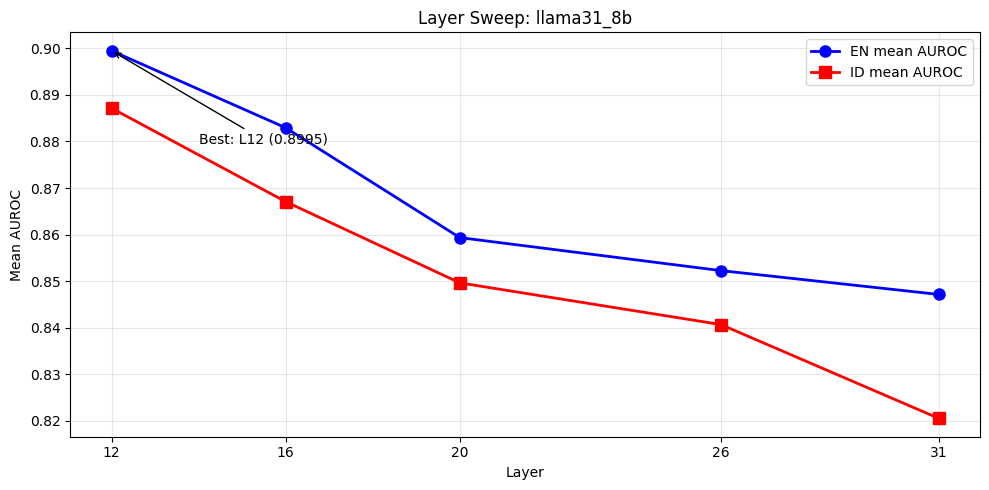


 Layer |   EN Synth |    EN Anth |    EN Tool |   ID Synth |    ID Anth |    ID Tool
------------------------------------------------------------------------------------------
    12 |     0.9961 |     0.8701 |     0.8324 |     0.9942 |     0.8279 |     0.8394
    16 |     0.9955 |     0.8443 |     0.8091 |     0.9932 |     0.8116 |     0.7964
    20 |     0.9953 |     0.8427 |     0.7400 |     0.9919 |     0.7977 |     0.7593
    26 |     0.9935 |     0.8031 |     0.7601 |     0.9883 |     0.7489 |     0.7848
    31 |     0.9923 |     0.7559 |     0.7932 |     0.9795 |     0.6710 |     0.8110


In [9]:
if len(LAYERS) > 1:
    layers   = sorted(all_results.keys())
    en_auroc = [np.mean([all_results[l][f"en_{ds}"]["auroc"] for ds in ["synthetic", "anthropic", "toolace"]]) for l in layers]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(layers, en_auroc, "b-o", label="EN mean AUROC", lw=2, ms=8)

    if EVAL_INDONESIAN:
        id_auroc = [np.mean([all_results[l][f"id_{ds}"]["auroc"] for ds in ["synthetic", "anthropic", "toolace"]]) for l in layers]
        ax.plot(layers, id_auroc, "r-s", label="ID mean AUROC", lw=2, ms=8)

    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean AUROC")
    ax.set_title(f"Layer Sweep: {MODEL_SHORT}")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(layers)

    best_layer = layers[np.argmax(en_auroc)]
    best_val   = max(en_auroc)
    ax.annotate(f"Best: L{best_layer} ({best_val:.4f})",
                xy=(best_layer, best_val),
                xytext=(best_layer + 2, best_val - 0.02),
                arrowprops=dict(arrowstyle="->"), fontsize=10)

    plt.tight_layout()
    plt.savefig(CACHE_DIR / f"{CACHE_PREFIX}_layer_sweep.png", dpi=150)
    plt.show()

    # per-dataset table
    print(f"\n{'Layer':>6} | {'EN Synth':>10} | {'EN Anth':>10} | {'EN Tool':>10}", end="")
    if EVAL_INDONESIAN:
        print(f" | {'ID Synth':>10} | {'ID Anth':>10} | {'ID Tool':>10}", end="")
    print()
    print("-" * (50 + (40 if EVAL_INDONESIAN else 0)))
    for l in layers:
        r = all_results[l]
        print(f"{l:>6} | {r['en_synthetic']['auroc']:>10.4f} | {r['en_anthropic']['auroc']:>10.4f} | {r['en_toolace']['auroc']:>10.4f}", end="")
        if EVAL_INDONESIAN:
            print(f" | {r['id_synthetic']['auroc']:>10.4f} | {r['id_anthropic']['auroc']:>10.4f} | {r['id_toolace']['auroc']:>10.4f}", end="")
        print()
else:
    print("Single layer evaluated -- no sweep plot needed.")

## Part 6: Error Analysis

In [10]:
probe_err = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{plot_layer}.pkl")

analyze_errors(probe_err, X_test_plot, test_data, "EN Synthetic")
analyze_errors(probe_err, X_anthropic_plot, anthropic_test, "EN Anthropic")
analyze_errors(probe_err, X_toolace_plot, toolace_test, "EN ToolACE")

if EVAL_INDONESIAN:
    X_id_test_plot = get_activations_cached(model, tokenizer, id_test_data, plot_layer,
                         cache_name="id_test_synthetic", cache_dir=CACHE_DIR,
                         cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)
    analyze_errors(probe_err, X_id_test_plot, id_test_data, "ID Synthetic")


ERROR ANALYSIS: EN Synthetic
Total errors: 55 / 2000 (2.8%)
False positives: 36
False negatives: 19

--- FALSE POSITIVES (predicted high, actually low) ---

P=0.973 | ID: TI8xJFja
  The COO, listening intently as the room filled with varied opinions, wrestled with the decision to prioritize financial prudence over the long-term strength of the company's sustainable brand reputati...

P=0.972 | ID: 2p0s9G1Q
  Imagine you're leading the city's IT team responsible for the public transportation system. In light of the recent data breach, what key actions would you prioritize to ensure system security is stren...

P=0.954 | ID: 4lLniJ7l
  Bitte dringend um Hilfe! Verdächtige Aktivitäten bemerkt. Wir intensivieren Sicherheitsmaßnahmen jedoch verunsichert. Rat notwendig. Hilfe gesucht.

P=0.936 | ID: OAVPnS9W
  पहले से ज्ञात नियमों की अनदेखी के चलते इस अनियंत्रित संकट का दोष किस पर डालेगा यह फिल्म दल? 

P=0.887 | ID: P4UcoB0y
  Sollten wir schnell reagieren und mehr Mittel für bestmöglichen 

## Part 7: Sense Checks

1. Training accuracy (overfitting check)
2. Random label baseline (should be ~0.5 AUROC)
3. Per-source-language breakdown of synthetic test set

In [12]:
probe_check = LinearProbe.load(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{plot_layer}.pkl")
X_train_check = get_activations_cached(model, tokenizer, train_data, plot_layer,
                    cache_name="train", cache_dir=CACHE_DIR,
                    cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE)

# 1. Training accuracy
train_metrics = evaluate_probe(probe_check, X_train_check, y_train, "Training Set (overfitting check)")

# 2. Random baseline
rng            = np.random.RandomState(RANDOM_SEED)
y_shuffled     = rng.permutation(y_train)
random_probe   = LinearProbe(C=1e-3)
random_probe.fit(X_train_check, y_shuffled)
random_metrics = evaluate_probe(random_probe, X_test_plot, y_test, "Random Labels Baseline")

# 3. Per-source-language breakdown
raw_test  = load_jsonl(DATASET_PATHS["test"])
languages = [row.get("language", "English") for row in raw_test]

print("\n--- Per-Source-Language Breakdown ---")
for lang in sorted(set(languages)):
    mask    = np.array([l == lang for l in languages])
    n_total = mask.sum()
    if n_total < 10:
        continue
    X_lang = X_test_plot[mask]
    y_lang = y_test[mask]
    probs  = probe_check.predict_proba(X_lang)
    auroc  = roc_auc_score(y_lang, probs)
    n_high = int(y_lang.sum())
    print(f"  {lang:12s}: AUROC={auroc:.4f}  ({n_total} examples, {n_high} high)")

Loading from cache: v2b_llama31_8b_train_layer12.npy

Training Set (overfitting check):
  AUROC:      0.9982
  Accuracy:   0.9825
  TPR@1%FPR:  0.9682
  TPR@5%FPR:  0.9940

Random Labels Baseline:
  AUROC:      0.5061
  Accuracy:   0.5000
  TPR@1%FPR:  0.0187
  TPR@5%FPR:  0.0674

--- Per-Source-Language Breakdown ---
  English     : AUROC=0.9957  (1172 examples, 570 high)
  French      : AUROC=0.9985  (275 examples, 128 high)
  German      : AUROC=0.9952  (289 examples, 139 high)
  Hindi       : AUROC=0.9962  (264 examples, 128 high)


## Part 8: Save Artifacts

In [13]:
results_path = CACHE_DIR / f"{CACHE_PREFIX}_results.json"
artifacts = {
    "version":         "v2b",
    "model_name":      MODEL_NAME,
    "model_short":     MODEL_SHORT,
    "layers":          LAYERS,
    "eval_indonesian": EVAL_INDONESIAN,
    "results":         {str(k): v for k, v in all_results.items()},
    "data_sizes": {
        "en_train":     len(train_data),
        "en_test":      len(test_data),
        "en_anthropic": len(anthropic_test),
        "en_toolace":   len(toolace_test),
    },
}
if EVAL_INDONESIAN:
    artifacts["data_sizes"].update({
        "id_test":      len(id_test_data),
        "id_anthropic": len(id_anthropic_test),
        "id_toolace":   len(id_toolace_test),
    })

with open(results_path, "w") as f:
    json.dump(artifacts, f, indent=2)
print(f"Results saved to {results_path.name}")

list_cache(CACHE_DIR, prefix=CACHE_PREFIX)
download_from_colab(CACHE_DIR, results_path.name, CACHE_PREFIX)

Results saved to v2b_llama31_8b_results.json

Cache directory: /lambda/nfs/default-filesystem/bluedot-project/experiments/cache
--------------------------------------------------
  v2b_llama31_8b_anthropic_test_layer12.npy        46.63 MB
  v2b_llama31_8b_anthropic_test_layer16.npy        46.63 MB
  v2b_llama31_8b_anthropic_test_layer20.npy        46.63 MB
  v2b_llama31_8b_anthropic_test_layer26.npy        46.63 MB
  v2b_llama31_8b_anthropic_test_layer31.npy        46.63 MB
  v2b_llama31_8b_id_anthropic_test_layer12.npy     46.23 MB
  v2b_llama31_8b_id_anthropic_test_layer16.npy     46.23 MB
  v2b_llama31_8b_id_anthropic_test_layer20.npy     46.23 MB
  v2b_llama31_8b_id_anthropic_test_layer26.npy     46.23 MB
  v2b_llama31_8b_id_anthropic_test_layer31.npy     46.23 MB
  v2b_llama31_8b_id_test_synthetic_layer12.npy     30.47 MB
  v2b_llama31_8b_id_test_synthetic_layer16.npy     30.47 MB
  v2b_llama31_8b_id_test_synthetic_layer20.npy     30.47 MB
  v2b_llama31_8b_id_test_synthetic_layer2